# Neural Network dự đoán Thermal Conductivity (TC) từ Formula + Temperature

Notebook này được viết lại theo style của `seminar07_LogReg_and_MLP.ipynb`:

- Dùng `torch.nn.Module` để xây dựng MLP.
- Dùng `CustomDataset` và `DataLoader`.
- Vòng lặp train/validation rõ ràng.
- Lưu model có validation loss nhỏ nhất.

**Input:** atomic percent từ `Formula` + `Temperature (K)`  
**Output:** `TC`


In [1]:
# Cell 1 - Import thư viện

import os
import re
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import Adam
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)
torch.cuda.manual_seed_all(RANDOM_STATE)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', DEVICE)


Device: cuda


In [2]:
# Cell 2 - Đọc dữ liệu

DATA_PATH = 'TC_filtered_final.csv'

df = pd.read_csv(DATA_PATH)
print(df.shape)
df.head()


(99772, 4)


,Formula,Temperature (K),TC,DOI
0,Ag0.003Bi2Te2.7Se0.3,300.269397,1.344737,10.1016/j.mtphys.2017.09.001
1,Ag0.003Bi2Te2.7Se0.3,323.976293,1.284211,10.1016/j.mtphys.2017.09.001
2,Ag0.003Bi2Te2.7Se0.3,349.838362,1.234211,10.1016/j.mtphys.2017.09.001
3,Ag0.003Bi2Te2.7Se0.3,375.161638,1.215789,10.1016/j.mtphys.2017.09.001
4,Ag0.003Bi2Te2.7Se0.3,399.946121,1.217105,10.1016/j.mtphys.2017.09.001


In [3]:
# Cell 3 - Kiểm tra dữ liệu cơ bản

print('Columns:', df.columns.tolist())
print('Missing values:')
print(df.isna().sum())

print('Statistical summary:')
df[['Temperature (K)', 'TC']].describe()


Columns: ['Formula', 'Temperature (K)', 'TC', 'DOI']
Missing values:
Formula            0
Temperature (K)    0
TC                 0
DOI                0
dtype: int64
Statistical summary:


,Temperature (K),TC
count,99772.000000,99772.000000
mean,399.657872,2.797600
std,245.834493,3.064312
min,0.000000,0.001038
25%,213.531612,1.102465
50%,382.121891,1.927612
75%,573.111873,3.302225
max,1475.680000,28.465949


In [4]:
# Cell 4 - Làm sạch dữ liệu

required_cols = ['Formula', 'Temperature (K)', 'TC']
for col in required_cols:
    if col not in df.columns:
        raise ValueError(f'Missing column: {col}')

df = df[required_cols].copy()

df['Formula'] = df['Formula'].astype(str).str.strip()
df['Temperature (K)'] = pd.to_numeric(df['Temperature (K)'], errors='coerce')
df['TC'] = pd.to_numeric(df['TC'], errors='coerce')

df.head()


,Formula,Temperature (K),TC
0,Ag0.003Bi2Te2.7Se0.3,300.269397,1.344737
1,Ag0.003Bi2Te2.7Se0.3,323.976293,1.284211
2,Ag0.003Bi2Te2.7Se0.3,349.838362,1.234211
3,Ag0.003Bi2Te2.7Se0.3,375.161638,1.215789
4,Ag0.003Bi2Te2.7Se0.3,399.946121,1.217105


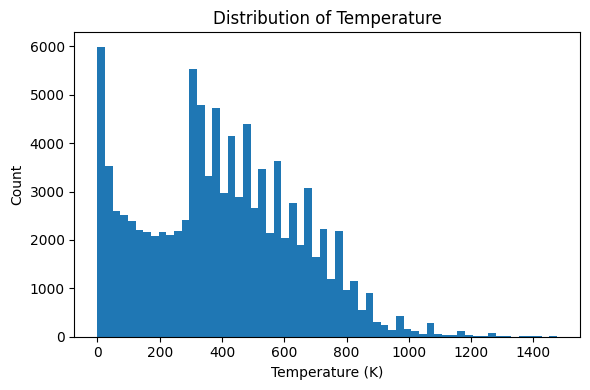

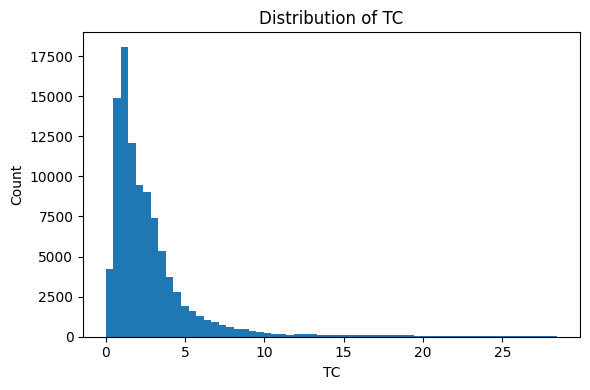

In [5]:
# Cell 5 - Vẽ phân bố Temperature và TC

plt.figure(figsize=(6,4))
plt.hist(df['Temperature (K)'], bins=60)
plt.xlabel('Temperature (K)')
plt.ylabel('Count')
plt.title('Distribution of Temperature')
plt.tight_layout()
plt.show()

plt.figure(figsize=(6,4))
plt.hist(df['TC'], bins=60)
plt.xlabel('TC')
plt.ylabel('Count')
plt.title('Distribution of TC')
plt.tight_layout()
plt.show()


In [6]:
# Cell 6 - Hàm parse Formula thành atomic percent

# Hàm này xử lý công thức kiểu: Bi2Te3, Ag0.1Bi2Te3, Fe0.5Co0.5, ...
# Nếu công thức có dạng phức tạp hơn, có thể cần bổ sung parser riêng.

PATTERN = re.compile(r'([A-Z][a-z]?)([0-9]*\.?[0-9]*)')

def formula_to_amount_dict(formula):
    formula = str(formula).replace(' ', '')
    tokens = PATTERN.findall(formula)
    if len(tokens) == 0:
        return None

    comp = {}
    for el, num in tokens:
        amount = 1.0 if num == '' else float(num)
        comp[el] = comp.get(el, 0.0) + amount
    return comp


def formula_to_atomic_percent(formula):
    comp = formula_to_amount_dict(formula)
    if comp is None:
        return None
    total = sum(comp.values())
    if total <= 0:
        return None
    return {el: amount / total for el, amount in comp.items()}

# Test nhanh
for f in ['Bi2Te3', 'Ag0.1Bi2Te3', 'Fe0.5Co0.5Ni']:
    print(f, formula_to_atomic_percent(f))


Bi2Te3 {'Bi': 0.4, 'Te': 0.6}
Ag0.1Bi2Te3 {'Ag': 0.019607843137254905, 'Bi': 0.3921568627450981, 'Te': 0.5882352941176471}
Fe0.5Co0.5Ni {'Fe': 0.25, 'Co': 0.25, 'Ni': 0.5}


In [7]:
# Cell 7 - Tạo feature matrix: atomic percent + Temperature

composition_list = []
valid_indices = []

for idx, formula in enumerate(df['Formula']):
    comp = formula_to_atomic_percent(formula)
    if comp is not None:
        composition_list.append(comp)
        valid_indices.append(idx)

df = df.iloc[valid_indices].reset_index(drop=True)

# Danh sách nguyên tố xuất hiện trong toàn bộ dataset
elements = sorted(set(el for comp in composition_list for el in comp.keys()))
print('Number of elements:', len(elements))
print(elements)

X_comp = pd.DataFrame(0.0, index=np.arange(len(df)), columns=elements)
for i, comp in enumerate(composition_list):
    for el, frac in comp.items():
        X_comp.loc[i, el] = frac

# Thêm temperature vào input
X = X_comp.copy()
X['Temperature (K)'] = df['Temperature (K)'].values

Y = df['TC'].values.reshape(-1, 1)

print('X shape:', X.shape)
print('y shape:', Y.shape)
X.head()


Number of elements: 50
['Ag', 'Al', 'Ba', 'Bi', 'C', 'Ca', 'Cd', 'Ce', 'Cl', 'Co', 'Cr', 'Cu', 'Dy', 'Er', 'Eu', 'Fe', 'Ga', 'Gd', 'Ge', 'Hf', 'Ho', 'I', 'In', 'La', 'Li', 'Mg', 'Mn', 'Mo', 'Na', 'Nb', 'Nd', 'Ni', 'O', 'Pb', 'S', 'Sb', 'Se', 'Si', 'Sm', 'Sn', 'Sr', 'Ta', 'Te', 'Ti', 'Tm', 'V', 'Y', 'Yb', 'Zn', 'Zr']
X shape: (99772, 51)
y shape: (99772, 1)


,Ag,Al,Ba,Bi,C,Ca,Cd,Ce,Cl,Co,...,Ta,Te,Ti,Tm,V,Y,Yb,Zn,Zr,Temperature (K)
0,0.0006,0.0,0.0,0.39976,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.539676,0.0,0.0,0.0,0.0,0.0,0.0,0.0,300.269397
1,0.0006,0.0,0.0,0.39976,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.539676,0.0,0.0,0.0,0.0,0.0,0.0,0.0,323.976293
2,0.0006,0.0,0.0,0.39976,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.539676,0.0,0.0,0.0,0.0,0.0,0.0,0.0,349.838362
3,0.0006,0.0,0.0,0.39976,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.539676,0.0,0.0,0.0,0.0,0.0,0.0,0.0,375.161638
4,0.0006,0.0,0.0,0.39976,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.539676,0.0,0.0,0.0,0.0,0.0,0.0,0.0,399.946121


In [8]:
# Cell 8 - Chia train/valid/test và scale dữ liệu

# Chia giống seminar07: train/val/test
X_train, X_temp, Y_train, Y_temp = train_test_split(
    X.values, Y, test_size=0.2, random_state=RANDOM_STATE
)
X_valid, X_test, Y_valid, Y_test = train_test_split(
    X_temp, Y_temp, test_size=0.5, random_state=RANDOM_STATE
)

print('Train:', X_train.shape, Y_train.shape)
print('Valid:', X_valid.shape, Y_valid.shape)
print('Test :', X_test.shape, Y_test.shape)


Train: (79817, 51) (79817, 1)
Valid: (9977, 51) (9977, 1)
Test : (9978, 51) (9978, 1)


In [9]:
# Cell 9 - Chuyển dữ liệu sang torch tensor

X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
X_valid_tensor = torch.tensor(X_valid, dtype=torch.float32)
X_test_tensor  = torch.tensor(X_test,  dtype=torch.float32)

Y_train_tensor = torch.tensor(Y_train, dtype=torch.float32)
Y_valid_tensor = torch.tensor(Y_valid, dtype=torch.float32)
Y_test_tensor  = torch.tensor(Y_test,  dtype=torch.float32)

print(X_train_tensor.shape, Y_train_tensor.shape)


torch.Size([79817, 51]) torch.Size([79817, 1])


In [10]:
# Cell 10 - Dataset và DataLoader giống seminar07

class CustomDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        x_sample = self.X[idx]
        y_sample = self.y[idx]
        return x_sample, y_sample


train_dataset = CustomDataset(X_train_tensor, Y_train_tensor)
valid_dataset = CustomDataset(X_valid_tensor, Y_valid_tensor)
test_dataset  = CustomDataset(X_test_tensor,  Y_test_tensor)

BATCH_SIZE = 128

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)

for X_batch, y_batch in train_loader:
    print('X batch:', X_batch.shape)
    print('y batch:', y_batch.shape)
    break


X batch: torch.Size([128, 51])
y batch: torch.Size([128, 1])


In [11]:
# Cell 11 - Xây dựng MLP Regression model theo style seminar07

class MLP(nn.Module):
    def __init__(self, input_dim, hidden_dim=256, out_dim=1):
        super().__init__()

        # input layer
        self.in_fc = nn.Linear(input_dim, hidden_dim)

        # hidden layers
        self.hidden_fc1 = nn.Linear(hidden_dim, hidden_dim)
        self.hidden_fc2 = nn.Linear(hidden_dim, hidden_dim // 2)
        self.hidden_fc3 = nn.Linear(hidden_dim // 2, hidden_dim // 4)

        # output layer
        self.out_fc = nn.Linear(hidden_dim // 4, out_dim)

        self.dropout = nn.Dropout(0.05)

    def forward(self, x):
        x = self.in_fc(x)
        x = F.relu(x)
        x = self.dropout(x)

        x = self.hidden_fc1(x)
        x = F.relu(x)
        x = self.dropout(x)

        x = self.hidden_fc2(x)
        x = F.relu(x)

        x = self.hidden_fc3(x)
        x = F.relu(x)

        x = self.out_fc(x)
        return x


input_dim = X_train_tensor.shape[1]
model = MLP(input_dim=input_dim, hidden_dim=256, out_dim=1).to(DEVICE)

criterion = nn.MSELoss()
optimizer = Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)

model


MLP(
  (in_fc): Linear(in_features=51, out_features=256, bias=True)
  (hidden_fc1): Linear(in_features=256, out_features=256, bias=True)
  (hidden_fc2): Linear(in_features=256, out_features=128, bias=True)
  (hidden_fc3): Linear(in_features=128, out_features=64, bias=True)
  (out_fc): Linear(in_features=64, out_features=1, bias=True)
  (dropout): Dropout(p=0.05, inplace=False)
)

In [12]:
# Cell 12 - Hàm train và evaluate

def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0

    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()
        y_pred = model(X_batch)
        loss = criterion(y_pred, y_batch)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * X_batch.size(0)

    return total_loss / len(loader.dataset)


def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    preds = []
    targets = []

    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            y_pred = model(X_batch)
            loss = criterion(y_pred, y_batch)

            total_loss += loss.item() * X_batch.size(0)
            preds.append(y_pred.cpu().numpy())
            targets.append(y_batch.cpu().numpy())

    preds = np.vstack(preds)
    targets = np.vstack(targets)
    return total_loss / len(loader.dataset), preds, targets


In [13]:
# Cell 13 - Huấn luyện model: chạy đủ tất cả epochs, không early stopping

EPOCHS = 1000

loss_history_train = []
loss_history_valid = []

best_valid_loss = np.inf
best_epoch = 0

for epoch in range(1, EPOCHS + 1):
    train_loss = train_one_epoch(model, train_loader, optimizer, criterion, DEVICE)
    valid_loss, _, _ = evaluate(model, valid_loader, criterion, DEVICE)

    loss_history_train.append(train_loss)
    loss_history_valid.append(valid_loss)

    # Vẫn lưu model tốt nhất theo valid loss, nhưng KHÔNG dừng sớm
    if valid_loss < best_valid_loss:
        best_valid_loss = valid_loss
        best_epoch = epoch
        torch.save(model.state_dict(), 'best_tc_mlp_model.pt')

    if epoch % 10 == 0 or epoch == 1:
        print(f'Epoch {epoch:03d} | Train loss: {train_loss:.6f} | Valid loss: {valid_loss:.6f}')

print('Training finished.')
print(f'Best epoch: {best_epoch}')
print(f'Best valid loss: {best_valid_loss:.6f}')
print('Saved best model: best_tc_mlp_model.pt')


Epoch 001 | Train loss: 9.613801 | Valid loss: 7.889318
Epoch 010 | Train loss: 4.333417 | Valid loss: 4.042129
Epoch 020 | Train loss: 3.741890 | Valid loss: 3.440826
Epoch 030 | Train loss: 3.289420 | Valid loss: 3.140360
Epoch 040 | Train loss: 3.096973 | Valid loss: 3.349695
Epoch 050 | Train loss: 2.924391 | Valid loss: 2.519431
Epoch 060 | Train loss: 2.840040 | Valid loss: 2.563172
Epoch 070 | Train loss: 2.746836 | Valid loss: 2.604700
Epoch 080 | Train loss: 2.666319 | Valid loss: 2.350990
Epoch 090 | Train loss: 2.675276 | Valid loss: 2.329231
Epoch 100 | Train loss: 2.575005 | Valid loss: 2.303043
Epoch 110 | Train loss: 2.570409 | Valid loss: 2.237943
Epoch 120 | Train loss: 2.503182 | Valid loss: 2.529776
Epoch 130 | Train loss: 2.477097 | Valid loss: 2.339567
Epoch 140 | Train loss: 2.411753 | Valid loss: 2.186432
Epoch 150 | Train loss: 2.450652 | Valid loss: 2.223248
Epoch 160 | Train loss: 2.353901 | Valid loss: 2.044185
Epoch 170 | Train loss: 2.321910 | Valid loss: 2

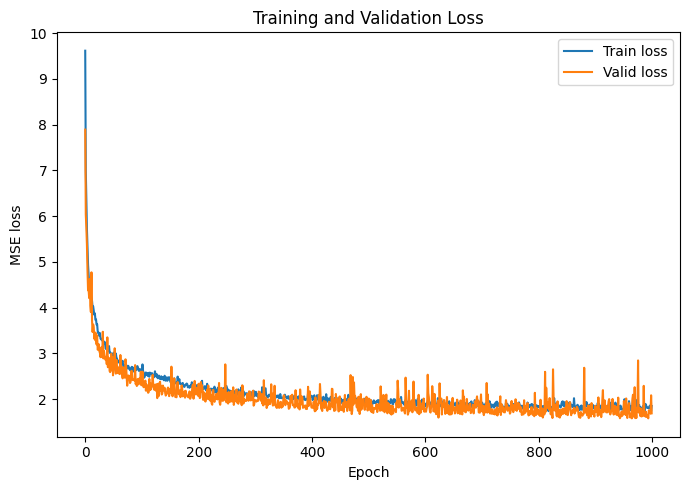

Saved: mlp_loss_curve.png


In [14]:
# Cell 14 - Vẽ đường train/valid loss

plt.figure(figsize=(7,5))
plt.plot(loss_history_train, label='Train loss')
plt.plot(loss_history_valid, label='Valid loss')
plt.xlabel('Epoch')
plt.ylabel('MSE loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.tight_layout()
plt.savefig('mlp_loss_curve.png', dpi=300)
plt.show()

print('Saved: mlp_loss_curve.png')


In [15]:
model.load_state_dict(torch.load('best_tc_mlp_model.pt', map_location=DEVICE))
model.to(DEVICE)

train_loss, train_pred, train_true = evaluate(model, train_loader, criterion, DEVICE)
valid_loss, valid_pred, valid_true = evaluate(model, valid_loader, criterion, DEVICE)
test_loss,  test_pred,  test_true  = evaluate(model, test_loader,  criterion, DEVICE)

def regression_metrics(y_true, y_pred):
    r2 = r2_score(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred) ** 0.5
    mae = mean_absolute_error(y_true, y_pred)
    return r2, rmse, mae


metrics = []

for name, yt, yp in [
    ('Train', train_true, train_pred),
    ('Valid', valid_true, valid_pred),
    ('Test',  test_true,  test_pred),
]:
    r2, rmse, mae = regression_metrics(yt, yp)
    metrics.append([name, r2, rmse, mae])

metrics_df = pd.DataFrame(
    metrics,
    columns=['Dataset', 'R2', 'RMSE', 'MAE']
)

metrics_df

,Dataset,R2,RMSE,MAE
0,Train,0.838952,1.227652,0.658542
1,Valid,0.827899,1.256916,0.666901
2,Test,0.815525,1.348208,0.688299


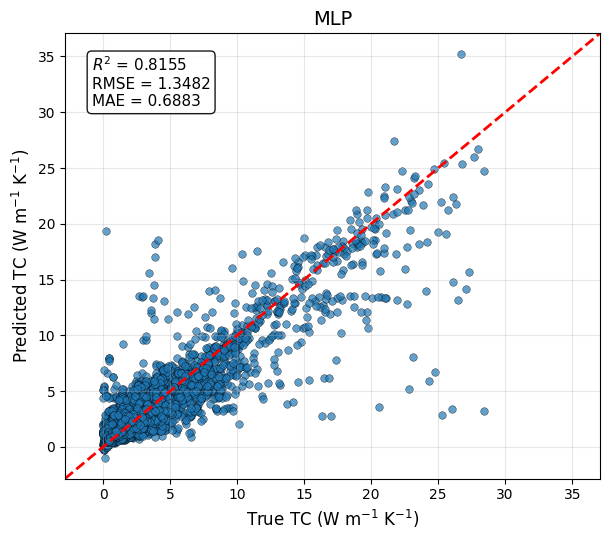

Saved: mlp_parity_plot.png


In [16]:
# Cell 16 - Parity plot trên tập test kèm metrics

import numpy as np
import matplotlib.pyplot as plt

# Chuyển dữ liệu về mảng 1 chiều
if torch.is_tensor(test_true):
    y_true = test_true.detach().cpu().numpy().ravel()
else:
    y_true = np.asarray(test_true).ravel()

if torch.is_tensor(test_pred):
    y_pred = test_pred.detach().cpu().numpy().ravel()
else:
    y_pred = np.asarray(test_pred).ravel()

# Tính metrics trên tập test
r2, rmse, mae = regression_metrics(y_true, y_pred)

# Xác định giới hạn chung cho hai trục
min_val = min(y_true.min(), y_pred.min())
max_val = max(y_true.max(), y_pred.max())

data_range = max_val - min_val
padding = 0.05 * data_range

plot_min = min_val - padding
plot_max = max_val + padding

# Vẽ parity plot
fig, ax = plt.subplots(figsize=(6.2, 5.5))

ax.scatter(
    y_true,
    y_pred,
    s=30,
    color='#1f77b4',
    alpha=0.70,
    edgecolors='black',
    linewidths=0.35
)

# Đường dự đoán lý tưởng y = x
ax.plot(
    [plot_min, plot_max],
    [plot_min, plot_max],
    color='red',
    linestyle='--',
    linewidth=2
)

# Chèn metrics vào biểu đồ
metrics_text = (
    rf'$R^2$ = {r2:.4f}' + '\n'
    rf'RMSE = {rmse:.4f}' + '\n'
    rf'MAE = {mae:.4f}'
)

ax.text(
    0.05,
    0.95,
    metrics_text,
    transform=ax.transAxes,
    fontsize=11,
    verticalalignment='top',
    horizontalalignment='left',
    bbox=dict(
        boxstyle='round',
        facecolor='white',
        edgecolor='black',
        alpha=0.90
    )
)

ax.set_xlim(plot_min, plot_max)
ax.set_ylim(plot_min, plot_max)

ax.set_xlabel(r'True TC (W m$^{-1}$ K$^{-1}$)', fontsize=12)
ax.set_ylabel(r'Predicted TC (W m$^{-1}$ K$^{-1}$)', fontsize=12)
ax.set_title('MLP', fontsize=14)

ax.grid(True, linestyle='-', linewidth=0.8, alpha=0.30)
ax.tick_params(axis='both', labelsize=10)

plt.tight_layout()
plt.savefig(
    'mlp_parity_plot.png',
    dpi=300,
    bbox_inches='tight'
)
plt.show()

print('Saved: mlp_parity_plot.png')

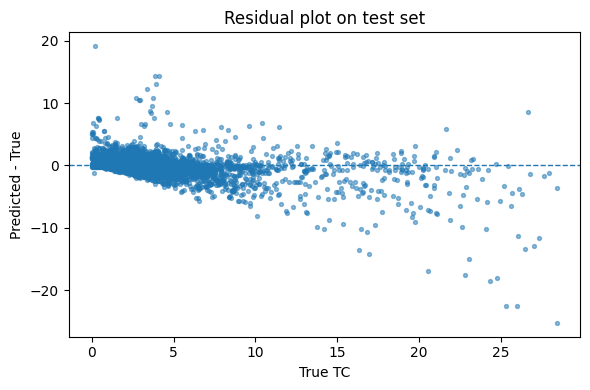

Saved: mlp_residual_plot.png


In [17]:
# Cell 17 - Vẽ residual plot

residual = test_pred - test_true

plt.figure(figsize=(6,4))
plt.scatter(test_true, residual, s=8, alpha=0.5)
plt.axhline(0, linestyle='--', linewidth=1)
plt.xlabel('True TC')
plt.ylabel('Predicted - True')
plt.title('Residual plot on test set')
plt.tight_layout()
plt.savefig('mlp_residual_plot.png', dpi=300)
plt.show()

print('Saved: mlp_residual_plot.png')


In [18]:
# Cell 19 - Hàm dự đoán TC cho dữ liệu mới
# Bản no-scale: dùng trực tiếp Formula + Temperature (K) -> TC

feature_columns = X.columns.tolist()


def make_features_for_prediction(input_df):
    rows = []

    for _, row in input_df.iterrows():
        comp = formula_to_atomic_percent(row["Formula"])

        feat = {col: 0.0 for col in feature_columns}

        if comp is not None:
            for el, frac in comp.items():
                if el in feat:
                    feat[el] = frac

        feat["Temperature (K)"] = float(row["Temperature (K)"])

        rows.append(feat)

    X_new = pd.DataFrame(rows)[feature_columns]

    # No scale
    return torch.tensor(X_new.values, dtype=torch.float32)


def predict_tc(input_df):
    model.eval()

    X_new_tensor = make_features_for_prediction(input_df).to(DEVICE)

    with torch.no_grad():
        pred_tc = model(X_new_tensor).cpu().numpy().reshape(-1)

    # Tránh TC âm nếu model dự đoán âm
    pred_tc = np.clip(pred_tc, 0, None)

    output_df = input_df.copy()
    output_df["TC_predicted"] = pred_tc

    return output_df


# Test nhanh
example_df = pd.DataFrame({
    "Formula": ["Bi2Te3", "PbTe"],
    "Temperature (K)": [300, 500]
})

predict_tc(example_df)

,Formula,Temperature (K),TC_predicted
0,Bi2Te3,300,1.159886
1,PbTe,500,1.949991


In [19]:
import pickle

artifacts = {
    'elements': elements,
    'feature_columns': feature_columns,
    'input_dim': len(feature_columns),
}

with open('mlp_preprocessing.pkl', 'wb') as f:
    pickle.dump(artifacts, f)

print('Saved: best_tc_mlp_model.pt')
print('Saved: mlp_preprocessing.pkl')

Saved: best_tc_mlp_model.pt
Saved: mlp_preprocessing.pkl
